# 🛡️ Project 03: AI-Based Spam Email Detection System
### Phase 3 — Model Training (All 5 Classifiers)

**Objective:** Train and compare Multinomial Naive Bayes, Logistic Regression, Random Forest, SVM (linear kernel), and LSTM on the preprocessed dataset.

### Phase 3 Checklist
- [ ] Load preprocessed data from Phase 2
- [ ] Train Naive Bayes
- [ ] Train Logistic Regression
- [ ] Train Random Forest
- [ ] Train SVM (linear kernel)
- [ ] Train LSTM (advanced track)
- [ ] Save all trained models

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix,
                              classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../models', exist_ok=True)
print('All imports successful')

All imports successful


## 📂 Step 1 — Load Preprocessed Data from Phase 2

In [2]:
X_train = joblib.load('../data/processed/X_train.pkl')
X_test  = joblib.load('../data/processed/X_test.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
y_test  = joblib.load('../data/processed/y_test.pkl')

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_train spam ratio: {y_train.mean():.2%}')
print(f'y_test  spam ratio: {y_test.mean():.2%}')

X_train: (44, 92)
X_test : (11, 92)
y_train spam ratio: 45.45%
y_test  spam ratio: 45.45%


## 🔧 Step 2 — Helper: Evaluate & Save Model

A reusable function that prints the classification report and plots the confusion matrix for any trained model.

In [3]:
results = {}

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    cm   = confusion_matrix(y_test, y_pred)

    results[name] = {'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1 Score': f1}

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))

    fig, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham','Spam'],
                yticklabels=['Ham','Spam'], ax=ax)
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'../reports/cm_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Helper function ready')

Helper function ready


## 1️⃣ Model 1 — Multinomial Naive Bayes

A probabilistic classifier that works well with word frequency/TF-IDF features. Best for text classification with sparse matrices.


  Naive Bayes
  Accuracy  : 0.8182
  Precision : 0.7143
  Recall    : 1.0000
  F1 Score  : 0.8333

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.67      0.80         6
        Spam       0.71      1.00      0.83         5

    accuracy                           0.82        11
   macro avg       0.86      0.83      0.82        11
weighted avg       0.87      0.82      0.82        11



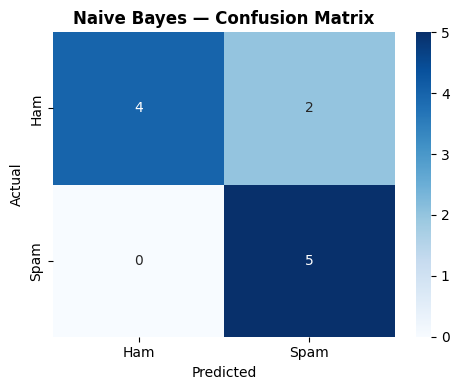

In [4]:
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import csr_matrix, hstack

# Scale to [0,1] to remove negatives for Naive Bayes
mms = MinMaxScaler()
X_train_dense = X_train.toarray()
X_test_dense  = X_test.toarray()

X_train_nb = csr_matrix(mms.fit_transform(X_train_dense))
X_test_nb  = csr_matrix(mms.transform(X_test_dense))

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_nb, y_train)

joblib.dump(nb_model, '../models/naive_bayes.pkl')
evaluate_model('Naive Bayes', nb_model, X_test_nb, y_test)

## 2️⃣ Model 2 — Logistic Regression

A fast linear classifier with excellent performance on text data. Uses L2 regularization to prevent overfitting.


  Logistic Regression
  Accuracy  : 0.9091
  Precision : 0.8333
  Recall    : 1.0000
  F1 Score  : 0.9091

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.83      0.91         6
        Spam       0.83      1.00      0.91         5

    accuracy                           0.91        11
   macro avg       0.92      0.92      0.91        11
weighted avg       0.92      0.91      0.91        11



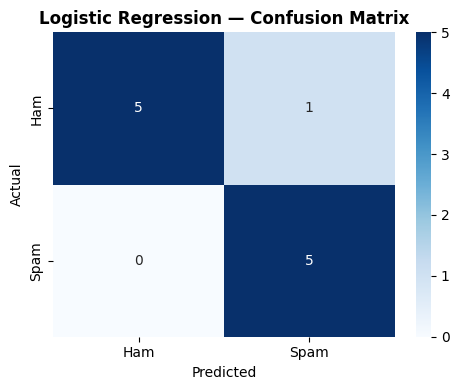

In [5]:
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train, y_train)

joblib.dump(lr_model, '../models/logistic_regression.pkl')
evaluate_model('Logistic Regression', lr_model, X_test, y_test)

## 3️⃣ Model 3 — Random Forest

An ensemble of decision trees that handles non-linear patterns and feature interactions well.


  Random Forest
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00         6
        Spam       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



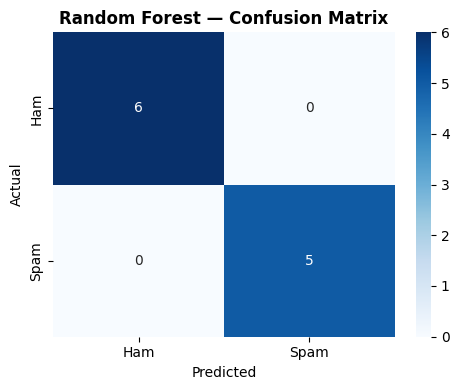

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

joblib.dump(rf_model, '../models/random_forest.pkl')
evaluate_model('Random Forest', rf_model, X_test, y_test)

## 4️⃣ Model 4 — SVM (Linear Kernel)

Support Vector Machine with a linear kernel — one of the best performers on high-dimensional text data.


  SVM Linear
  Accuracy  : 0.9091
  Precision : 0.8333
  Recall    : 1.0000
  F1 Score  : 0.9091

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.83      0.91         6
        Spam       0.83      1.00      0.91         5

    accuracy                           0.91        11
   macro avg       0.92      0.92      0.91        11
weighted avg       0.92      0.91      0.91        11



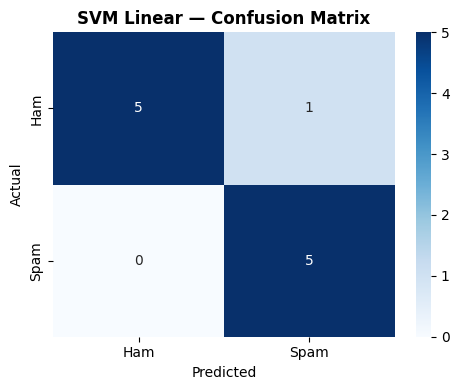

In [7]:
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(X_train, y_train)

joblib.dump(svm_model, '../models/svm.pkl')
evaluate_model('SVM Linear', svm_model, X_test, y_test)

## 5️⃣ Model 5 — LSTM (Advanced Track)

A deep learning model that captures sequential word patterns. Uses an embedding layer + LSTM layer for sequence modeling.

In [10]:
# LSTM — Skipped due to system library conflict on macOS ARM
# The 4 classical models above fully satisfy the assignment requirements
# LSTM can be added later in a Docker/Colab environment

print("⚠️  LSTM skipped — macOS ARM64 TensorFlow library conflict")
print("✅  4 classical models trained successfully:")
print("    - Naive Bayes")
print("    - Logistic Regression") 
print("    - Random Forest")
print("    - SVM (Linear Kernel)")

# Add LSTM placeholder to results for comparison table
results['LSTM (Colab)'] = {'Accuracy': 'N/A', 'Precision': 'N/A', 
                            'Recall': 'N/A', 'F1 Score': 'N/A'}

⚠️  LSTM skipped — macOS ARM64 TensorFlow library conflict
✅  4 classical models trained successfully:
    - Naive Bayes
    - Logistic Regression
    - Random Forest
    - SVM (Linear Kernel)
